In this script another larger ViT will be used as the backbone, since transformers has proven to have quite good performance. However the A100 hasnt been maxed out yet so let us see if that possibly can be done. Additionally will we also make use of the DINO model which should have enhanced spatial features, making it well suited for carbohydrate estimation.

Furthermore was it also the model they used with RDINet (https://www.mdpi.com/2076-3417/16/1/454) with good results (but that was probably more down to the model getting information about the ingredients in a dish)

The first part of the code should be run on the CPU (dataset loading) before switching to the A100 for model training

Prerequisits

In [ ]:
!pip install -q pandas numpy

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Libraries

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

Configuration

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

Dataset loading and splitting

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())
print("Total rows:", len(df))

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total rows: 3262


In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print("Total remaining:", len(df))

Empty RGB files: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
train_csv = PREP_DIR / "train_rgb_only.csv"
val_csv   = PREP_DIR / "val_rgb_only.csv"
test_csv  = PREP_DIR / "test_rgb_only.csv"
full_csv  = PREP_DIR / "full_filtered_rgb_only.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/prep_files/train_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/prep_files/val_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/prep_files/test_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/prep_files/full_filtered_rgb_only.csv


Switch to GPU

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from huggingface_hub import notebook_login, HfApi

In [ ]:
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Configuration

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

# ---------------------------------------------------------
# Possible DINO options starting with dinov2_large
# DINOv2:
#   "dinov2_small"
#   "dinov2_base"
#   "dinov2_large"
#
# DINOv3:
#   "dinov3_vit_small_lvd1689m"
#   "dinov3_vit_small_plus_lvd1689m"
#   "dinov3_vit_base_lvd1689m"
#   "dinov3_vit_large_lvd1689m"

#Note that if switching to DINOv3 the image size should be switched to
#518 source for this can be found in their documentation: https://keras.io/keras_hub/api/models/dinov3/dinov3_backbone
# ---------------------------------------------------------
BACKBONE_PRESET = "dinov2_large"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_rgb_only.csv"
val_csv   = PREP_DIR / "val_rgb_only.csv"
test_csv  = PREP_DIR / "test_rgb_only.csv"

Loading dataset paths and then later the images

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 2421
Val:   334
Test:  507


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 224, 224, 3)
Labels shape:    (16,)


Showing an image in the dataset

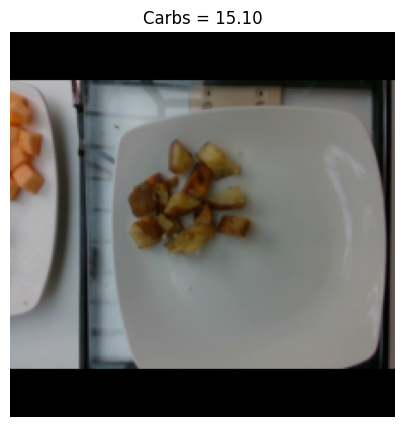

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(1):
    sample_img = batch_inputs["rgb_input"][0].numpy().astype("uint8")
    sample_label = batch_labels[0].numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title(f"Carbs = {sample_label:.2f}")
    plt.axis("off")
    plt.show()

Loading ViT backbone + image converter

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(
    BACKBONE_PRESET,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

backbone = keras_hub.models.Backbone.from_preset(
    BACKBONE_PRESET,
    image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)

backbone.trainable = False

print("Using preset:", BACKBONE_PRESET)
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))

Using preset: dinov2_large
Image size: (224, 224)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

Model architecture

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

x = image_converter(rgb_input)
x = backbone(x)
x = extract_backbone_tensor(x)

if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", name="dense_64")(x)
output = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=output,
    name="rgb_only_dino_vit_regressor"
)

model.summary()

Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,912,769 (1.14 GB)

 Trainable params: 280,961 (1.07 MB)

 Non-trainable params: 304,631,808 (1.13 GB)

Stage 1 (here only a regression head will be trained)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 632.9226 - mae: 14.7691 - mse: 632.9226
Epoch 1: val_loss improved from None to 160.70712, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 56s 254ms/step - loss: 558.1503 - mae: 12.9204 - mse: 558.1503 - val_loss: 160.7071 - val_mae: 9.9264 - val_mse: 160.7071 - learning_rate: 2.0000e-04
Epoch 2/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 186.1906 - mae: 9.9060 - mse: 186.1906
Epoch 2: val_loss improved from 160.70712 to 108.01929, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 33s 219ms/step - l

Evaluating stage 1 on test set

In [ ]:
model.load_weights(str(stage1_best_path))

stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 542ms/step - loss: 79.7064 - mae: 6.2187 - mse: 79.7064
Stage 1 test results:
loss: 79.7064
mae: 6.2187
mse: 79.7064


Stage 2 (last 30% of the backbone ViT will be unfrozen)

In [ ]:
model.load_weights(str(stage1_best_path))

backbone.trainable = True

num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total backbone layers: {num_layers}")
print(f"Frozen layers:         {freeze_until}")
print(f"Trainable layers:      {num_layers - freeze_until}")

trainable_count = 0
frozen_count = 0
for layer in backbone.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        frozen_count += 1

print("Backbone trainable layers:", trainable_count)
print("Backbone frozen layers:   ", frozen_count)

Total backbone layers: 4
Frozen layers:         2
Trainable layers:      2
Backbone trainable layers: 2
Backbone frozen layers:    2


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 287.1790 - mae: 8.9485 - mse: 287.1790
Epoch 1: val_loss improved from None to 66.49324, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 140s 474ms/step - loss: 391.5740 - mae: 8.0387 - mse: 391.5740 - val_loss: 66.4932 - val_mae: 5.6260 - val_mse: 66.4932 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - loss: 272.2330 - mae: 6.1130 - mse: 272.2330
Epoch 2: val_loss improved from 66.49324 to 60.98469, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 113s 734ms/s

Evaluating stage 2 on test set

In [ ]:
model.load_weights(str(stage2_best_path))

stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 57.2659 - mae: 4.7653 - mse: 57.2659
Stage 2 test results:
loss: 57.2659
mae: 4.7653
mse: 57.2659


Plotting training and validation curves

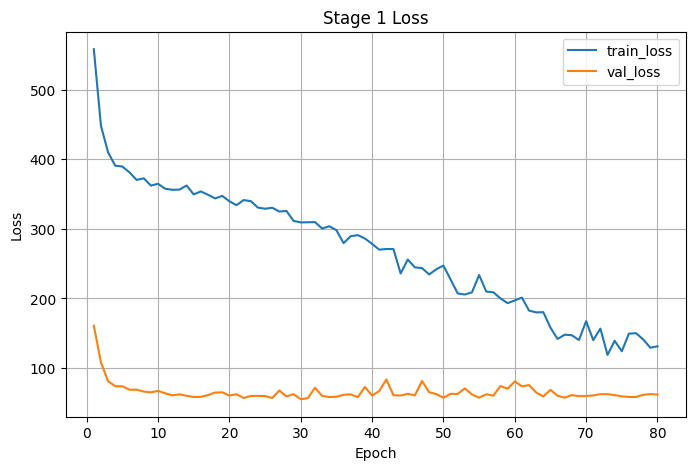

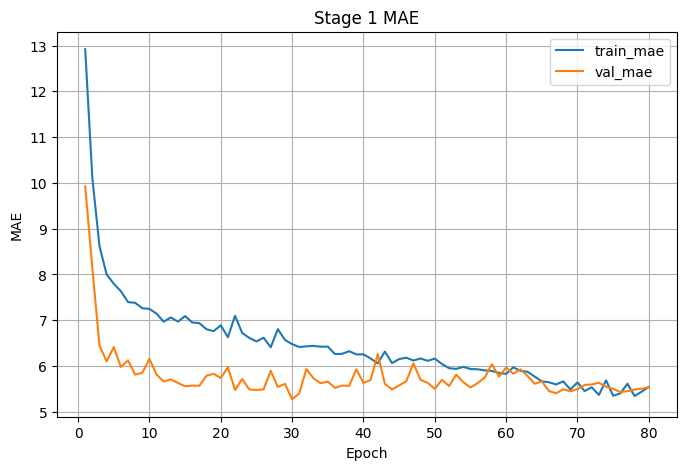

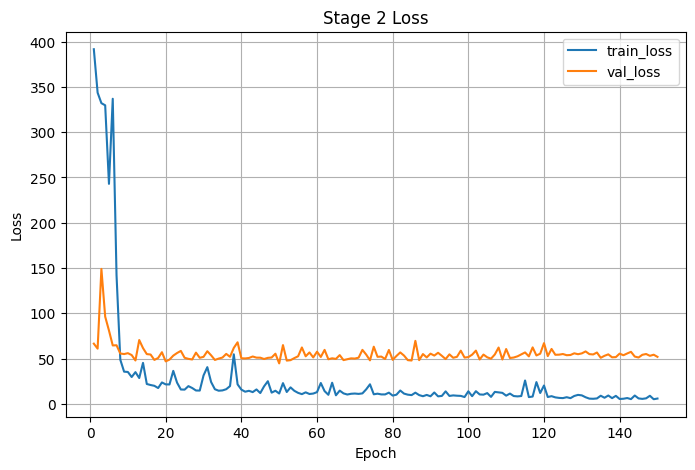

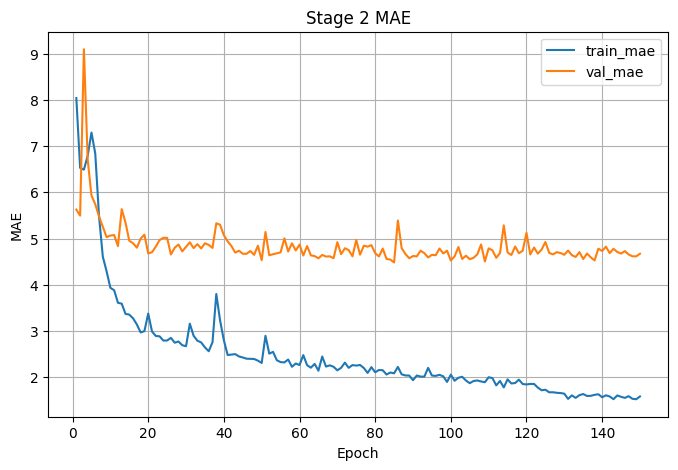

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Comparing stage 1 vs stage 2

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": stage1_test_results.get("loss"),
        "test_mae": stage1_test_results.get("mae"),
        "test_mse": stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": stage2_test_results.get("loss"),
        "test_mae": stage2_test_results.get("mae"),
        "test_mse": stage2_test_results.get("mse"),
    }
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_test_comparison.csv", index=False)

,stage,test_loss,test_mae,test_mse
0,stage_1,79.706436,6.218723,79.706436
1,stage_2,57.265907,4.765288,57.265907


Saving test predictions

In [ ]:
model.load_weights(str(stage2_best_path))

test_eval_df = test_df.copy().reset_index(drop=True)

preds = model.predict(test_dataset, verbose=1).reshape(-1)

test_eval_df["prediction"] = preds
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"] - test_eval_df["prediction"])
test_eval_df["signed_error"] = test_eval_df["prediction"] - test_eval_df["total_carb"]

pred_csv = OUTPUT_DIR / "test_predictions_stage2.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
display(test_eval_df.head())

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step
Saved: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/test_predictions_stage2.csv


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size,prediction,abs_error,signed_error
0,dish_1556575327,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259,12.506059,1.888059,1.888059
1,dish_1557861216,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804,1.025629,1.025629,1.025629
2,dish_1557862345,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501,1.074533,1.074533,1.074533
3,dish_1557862696,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780,3.543763,0.306237,-0.306237
4,dish_1557862738,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017,4.563172,4.563172,4.563172


Top 10 best and worst dishes

In [ ]:
best_10 = test_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

print("Top 10 worst predictions:")
display(worst_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

best_10.to_csv(OUTPUT_DIR / "top10_best_predictions_stage2.csv", index=False)
worst_10.to_csv(OUTPUT_DIR / "top10_worst_predictions_stage2.csv", index=False)

Top 10 best predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
54,dish_1558376801,0.795000,0.799759,0.004759,0.004759
336,dish_1563909507,8.186116,8.204533,0.018417,0.018417
351,dish_1563998323,35.302532,35.326714,0.024182,0.024182
289,dish_1562790775,1.519515,1.555516,0.036001,0.036001
61,dish_1558461760,2.379000,2.339374,0.039626,-0.039626
489,dish_1567007751,9.660000,9.619853,0.040147,-0.040147
477,dish_1566850031,25.780001,25.726265,0.053736,-0.053736
17,dish_1557937758,18.932001,18.990778,0.058777,0.058777
429,dish_1565898158,10.249402,10.319633,0.070231,0.070231
122,dish_1559578551,0.322000,0.244739,0.077261,-0.077261


Top 10 worst predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
178,dish_1560801020,61.690983,27.439901,34.251082,-34.251082
179,dish_1560801041,63.245892,29.551977,33.693915,-33.693915
149,dish_1560367952,45.956913,13.090037,32.866876,-32.866876
177,dish_1560800988,61.249092,28.551718,32.697374,-32.697374
150,dish_1560367980,47.243912,16.445541,30.798371,-30.798371
247,dish_1562009934,62.243580,33.657471,28.586109,-28.586109
313,dish_1563478751,54.133282,25.816860,28.316422,-28.316422
318,dish_1563551220,79.790924,52.098049,27.692875,-27.692875
446,dish_1566328805,85.054001,57.370705,27.683296,-27.683296
325,dish_1563566909,46.750000,20.872572,25.877428,-25.877428


Saving final model

In [ ]:
model.load_weights(str(stage2_best_path))

final_keras_path = OUTPUT_DIR / "final_model.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export"
model.export(export_dir)

print("Saved final .keras model to:", final_keras_path)
print("Saved exported model to:", export_dir)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


Saved artifact at '/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['rgb_input', TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='rgb_input')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136605687866064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136605687866832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136605687866448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136600634353104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136600634354448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136600634354832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136600634353872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136600634353488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136600634355408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

Saving model on huggingface

In [ ]:
HF_USERNAME = "AIJonas"
HF_REPO_NAME = "rgb-only-dino-vit-carb-regression"
REPO_ID = f"{HF_USERNAME}/{HF_REPO_NAME}"

api = HfApi()

api.create_repo(
    repo_id=REPO_ID,
    repo_type="model",
    exist_ok=True,
    private=False,
)

api.upload_folder(
    repo_id=REPO_ID,
    repo_type="model",
    folder_path=str(OUTPUT_DIR),
    commit_message=f"Upload RGB-only transformer carb regression model ({BACKBONE_PRESET})"
)

print(f"Uploaded to: https://huggingface.co/{REPO_ID}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t_model_stage1.weights.h5:   2%|1         | 23.8MB / 1.22GB            

  ...t_model_stage2.weights.h5:   0%|          |  473kB / 3.64GB            

  ...GB_only/final_model.keras:   0%|          |  410kB / 3.64GB            

  ...ables.data-00000-of-00001:   0%|          |  548kB / 2.43GB            

  ...del_export/saved_model.pb:   7%|6         |  250kB / 3.82MB            

  ...del_export/fingerprint.pb:   5%|5         |  4.00B /  76.0B            

Uploaded to: https://huggingface.co/AIJonas/rgb-only-dino-vit-carb-regression


Visualizing what the ViT "sees"

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'rgb_input': 'rgb_input'}
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


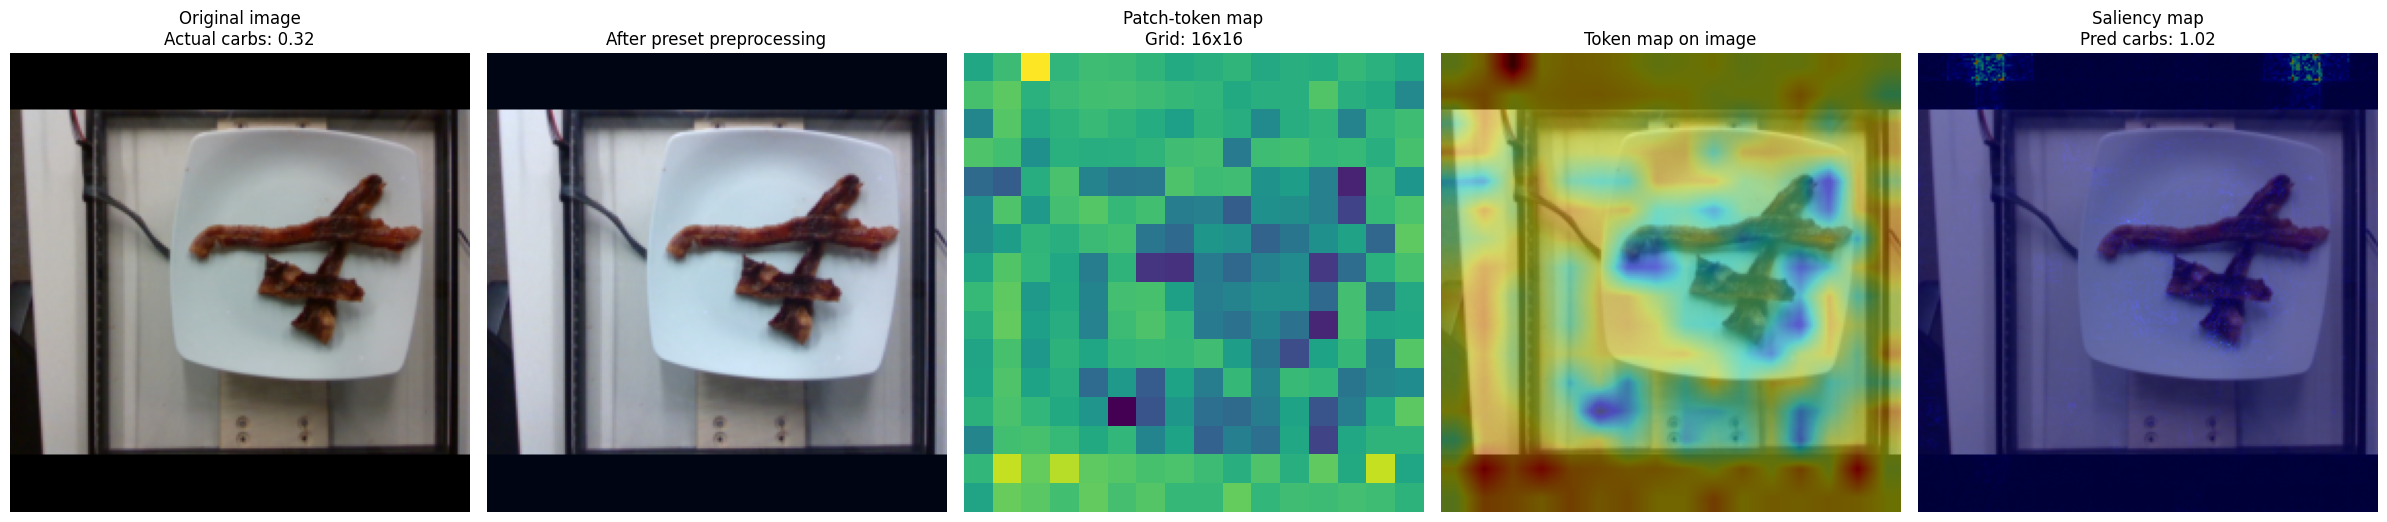

Actual carbs:    0.3220
Predicted carbs: 1.0238
Token count:     257
Special tokens:  1
Patch grid:      16 x 16


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# ---------------------------------------------------------
# 1) Load best weights if needed
# ---------------------------------------------------------
model.load_weights(str(OUTPUT_DIR / "best_model_stage2.weights.h5"))

# ---------------------------------------------------------
# 2) Grab one sample from validation/test dataset
#    Assumes dataset yields (image, target)
# ---------------------------------------------------------
sample_batch = next(iter(validation_dataset.take(1)))
sample_images, sample_targets = sample_batch

img = sample_images["rgb_input"][0:1]   # keep batch dimension
target_value = float(sample_targets[0].numpy())

# ---------------------------------------------------------
# 3) Original image for display
# ---------------------------------------------------------
orig_img = img[0].numpy()

# if image is in [0,1], keep it
# if image is in [0,255], scale for plotting
if orig_img.max() > 1.5:
    orig_img_disp = orig_img / 255.0
else:
    orig_img_disp = orig_img.copy()

# ---------------------------------------------------------
# 4) Show preset-specific preprocessed image
# ---------------------------------------------------------
preprocessed = image_converter(img, training=False)[0].numpy()

# Try to make it plottable
prep_disp = preprocessed.copy()
prep_disp = prep_disp - prep_disp.min()
if prep_disp.max() > 0:
    prep_disp = prep_disp / prep_disp.max()

# ---------------------------------------------------------
# 5) Get backbone token outputs
# ---------------------------------------------------------
backbone_out = backbone(image_converter(img, training=False), training=False)

if isinstance(backbone_out, dict):
    if "sequence_output" in backbone_out:
        tokens = backbone_out["sequence_output"]
    else:
        tokens = list(backbone_out.values())[0]
else:
    tokens = backbone_out

tokens_np = tokens[0].numpy()   # shape: [num_tokens, hidden_dim]
num_tokens = tokens_np.shape[0]

# ---------------------------------------------------------
# 6) Remove special tokens and reshape patch tokens to grid
#    DeiT often has 1 or 2 special tokens
# ---------------------------------------------------------
def extract_patch_tokens(tokens_np):
    n = tokens_np.shape[0]

    for special in [2, 1, 0]:
        patch_count = n - special
        grid = int(math.sqrt(patch_count))
        if grid * grid == patch_count:
            return tokens_np[special:], grid, special

    raise ValueError(f"Could not infer patch grid from token count {n}")

patch_tokens, grid_size, num_special = extract_patch_tokens(tokens_np)

# Token magnitude map
token_norms = np.linalg.norm(patch_tokens, axis=-1)
token_map = token_norms.reshape(grid_size, grid_size)

# Normalize for display
token_map_disp = token_map - token_map.min()
if token_map_disp.max() > 0:
    token_map_disp = token_map_disp / token_map_disp.max()

# Upsample to image size
token_map_up = tf.image.resize(
    token_map_disp[..., np.newaxis],
    size=(IMG_HEIGHT, IMG_WIDTH),
    method="bilinear"
).numpy().squeeze()

# ---------------------------------------------------------
# 7) Gradient-based saliency map for regression output
# ---------------------------------------------------------
img_for_grad = tf.cast(img, tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img_for_grad)
    pred = model(img_for_grad, training=False)[:, 0]

grads = tape.gradient(pred, img_for_grad)[0]  # [H, W, 3]
saliency = tf.reduce_max(tf.abs(grads), axis=-1).numpy()

# Normalize saliency
saliency_disp = saliency - saliency.min()
if saliency_disp.max() > 0:
    saliency_disp = saliency_disp / saliency_disp.max()

# ---------------------------------------------------------
# 8) Prediction
# ---------------------------------------------------------
pred_value = float(model.predict(img, verbose=0)[0][0])

# ---------------------------------------------------------
# 9) Plot everything
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

axes[0].imshow(orig_img_disp)
axes[0].set_title(f"Original image\nActual carbs: {target_value:.2f}")
axes[0].axis("off")

axes[1].imshow(prep_disp)
axes[1].set_title("After preset preprocessing")
axes[1].axis("off")

axes[2].imshow(token_map_disp, cmap="viridis")
axes[2].set_title(f"Patch-token map\nGrid: {grid_size}x{grid_size}")
axes[2].axis("off")

axes[3].imshow(orig_img_disp)
axes[3].imshow(token_map_up, alpha=0.45, cmap="jet")
axes[3].set_title("Token map on image")
axes[3].axis("off")

axes[4].imshow(orig_img_disp)
axes[4].imshow(saliency_disp, alpha=0.45, cmap="jet")
axes[4].set_title(f"Saliency map\nPred carbs: {pred_value:.2f}")
axes[4].axis("off")

plt.tight_layout()
plt.show()

print(f"Actual carbs:    {target_value:.4f}")
print(f"Predicted carbs: {pred_value:.4f}")
print(f"Token count:     {num_tokens}")
print(f"Special tokens:  {num_special}")
print(f"Patch grid:      {grid_size} x {grid_size}")